# Universidade Federal de São João del-Rei

# Machine Learning Aplicado à Engenharia

# Trabalho 2 (T2) — Modelagem, Validação e Comparação de Modelos de Aprendizado de Máquina

**Tema:** Análise Exploratória de Sinais EEG para Monitoramento e Classificação de Estados de Sono em Janelas de 30 Segundos

**Base utilizada:** _Sleep-EDF Database Expanded_

**Fonte:** https://www.physionet.org/content/sleep-edfx/1.0.0/

# Referência da Base

- B Kemp, AH Zwinderman, B Tuk, HAC Kamphuisen, JJL Oberyé. _Analysis of a sleep-dependent neuronal feedback loop: the slow-wave microcontinuity of the EEG_. IEEE-BME 47(9):1185-1194 (2000).

# Citação Padrão para PhysioNet

- Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, PC, Mark, R., ... & Stanley, HE (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220. RRID:SCR_007345.

**Integrantes do grupo:**
- Ícaro Ferreira dos Santos
- Wendell Christian Calixto Pinto
- Gabriel Augusto Silva Batista

**Repositório do grupo:**  
https://github.com/gabrielbtt/analise-estados-sono-eeg

# Convenção de Cores para Identificar Contribuições
- <font color="blue">Azul:</font> Ícaro Ferreira dos Santos
- <font color="green">Verde:</font> Wendell Christian Calixto Pinto
- <font color="red">Vermelho:</font> Gabriel Augusto Silva Batista

# Definição do Problema <font color="blue">(Ícaro)</font>

O problema escolhido neste trabalho consiste na **classificação automática dos estágios do sono** a partir de sinais de EEG do canal Fpz-Cz. A análise manual de polissonografias é um processo demorado, subjetivo e altamente dependente da experiência do técnico. Um sistema automatizado torna o diagnóstico mais rápido, objetivo e acessível, reduzindo a variabilidade entre profissionais.

Trata-se de um **problema de classificação supervisionada multiclasse**, cuja variável alvo (`y`) é a coluna `id_estagio`, derivada da coluna `estagio`, contendo cinco categorias discretas: Vigília (W), N1, N2, N3 (sono profundo) e REM.

As variáveis de entrada (atributos `X`) são compostas por características extraídas de cada época de 30 segundos, divididas em dois grupos principais:
- Características Estatísticas: média, desvio padrão, variância, valor RMS, assimetria e curtose da amplitude do sinal;
- Características Espectrais: potência absoluta e relativa nas bandas Delta (0,5-4 Hz), Theta (4-8 Hz), Alpha (8-13 Hz) e Beta (13-30 Hz), além de razões espectrais (como Delta/Alpha e Delta/Theta).

Essas variáveis foram selecionadas porque capturam propriedades fisiológicas críticas dos estágios do sono. A **potência delta** discrimina o sono profundo (N3), o **valor RMS** reflete a energia total do sinal em cada época, e a **assimetria** ajuda a identificar a instabilidade característica da vigília e do sono leve.

Apesar dos avanços, a base apresenta algumas limitações importantes: o estágio N2 é predominante (42,43% das épocas), enquanto o N1 é raro (8,03%), o que pode enviesar o modelo. Além disso, estágios fisiologicamente próximos, como N1 e REM, apresentam assinaturas estatísticas semelhantes, dificultando a definição de fronteiras de decisão. Por fim, diferenças individuais entre pacientes podem afetar a capacidade de generalização do modelo.


# Descrição da Base de Dados

A base utilizada é a *Sleep-EDF Database Expanded*, obtida via [PhysioNet](https://www.physionet.org/content/sleep-edfx/1.0.0/). Trata-se de um conjunto de dados reais de polissonografia voltado para o estudo da arquitetura do sono.

Os dados dos sinais polissonográficos (arquivos com extensão .PSG.edf) estão no formato EDF (*European Data Format*), contendo EEG (eletrodos Fpz-Cz e Pz-Oz), EOG (horizontal), EMG submentoniano, um marcador de evento e, geralmente, também sinais de respiração oronasal e temperatura corporal retal. Os hipnogramas, anotações dos estágios do sono, armazenados em arquivos com extensão *.Hypnogram.edf, estão no formato EDF+. Os arquivos são nomeados no padrão SC4 ssN EO-PSG.edf, em que "ss" corresponde ao número do sujeito e "N" é noite de coleta.

> **Sinais Utilizados:** Foram extraídas características do canal de EEG Fpz-Cz, com frequência de amostragem de 100 Hz.

> Os hipnogramas foram anotados manualmente por técnicos treinados seguindo o padrão Rechtschaffen & Kales, dividindo o registro em épocas de 30 segundos.

Além disso, problema consiste em uma classificação multiclasse com 5 categorias discretas:

- W (Vigília): momento em que a pessoa está acordada ou quase acordando;
- N1: sono leve de transição (fácil de acordar);
- N2: sono mais estável, que ocupa a maior parte da noite;
- N3: sono profundo, importante para recuperação física do corpo;
- R (REM): sono dos sonhos, essencial para a memória e o equilíbrio emocional.

**Escopo do Trabalho**

Para este trabalho, foram utilizados 20 pares de arquivos do banco Sleep-EDF Expanded, do registro `SC4001E` ao `SC4092E`. Essa expansão permite treinar o modelo com um volume significativamente maior de épocas em comparação ao estudo exploratório inicial, que utilizou apenas uma noite de um único paciente.

A base consolidada (`dados_epocas.csv`) possui 21.039 épocas de 30 segundos e foi gerada a partir dos arquivos EDF por meio da biblioteca MNE. Para o SVM, a separação entre treino e teste é feita por noite (`chavepar`), de forma a avaliar melhor a capacidade de generalização para registros não vistos.


# Conclusões do T1 e Motivação para o T2

A análise exploratória realizada no T1 consolidou a base `Sleep-EDF Expanded` como um conjunto de dados estruturado e tecnicamente justificado para tarefas de aprendizado de máquina. As principais conclusões que motivam este Trabalho 2 são:

- A **Potência Delta** é a característica mais robusta para distinguir o sono profundo (N3), com valores superiores aos estágios de sono leve.
- O valor **RMS** validou a realidade biológica do sono, sendo mais elevado no estágio N3 devido à grande amplitude das ondas lentas.
- A segmentação dos sinais brutos em épocas de 30 segundos transforma registros longos de EEG em amostras compactas e interpretáveis. No T2, a base consolidada passou a reunir **21.039 épocas** de 20 noites, tornando o conjunto mais adequado à aplicação de modelos de classificação multiclasse.

Embora o sono seja um processo cíclico e sequencial, no qual cada estágio é influenciado pelo anterior, como evidenciado pelo hipnograma no T1, o objetivo deste trabalho é realizar uma classificação multiclasse baseada nas características extraídas individualmente de cada época de 30 segundos (tais como valor RMS e potência nas bandas de frequência).

Dessa forma, cada janela de 30 segundos é tratada como uma amostra independente para o classificador. Essa abordagem justifica a concatenação dos dados de todas as noites e pacientes em um único *DataFrame* para treinamento. No entanto, devido à natureza temporal inerente ao sono, dois cuidados críticos devem ser observados:

  1. Para garantir a generalização e evitar o "vazamento de dados" (*data leakage*), a separação entre treino e teste deve ser feita por noites inteiras ou pacientes, garantindo que o modelo aprenda padrões universais e não apenas decore um indivíduo específico.
  2. A ordem sequencial dentro de cada noite deve ser preservada para futuras análises de contexto temporal e transições biológicas.


# Descrição das Variáveis

O conjunto de dados consolidado (`dados_epocas.csv`) contém **29 colunas**, organizadas da seguinte forma:

- Variáveis Identificadoras: `chavepar`, `indice_epoca` e `estagio` (variável alvo).
- Características Estatísticas (*Features*): média, desvio padrão, variância, valor RMS, assimetria e curtose da amplitude do sinal (em µV).
- Características Espectrais (*Features*): potência absoluta e relativa nas bandas Delta (0,5–4 Hz), Theta (4–8 Hz), Alpha (8–13 Hz) e Beta (13–30 Hz), além de razões espectrais (ex.: Delta/Alpha e Delta/Theta).

Essas variáveis foram extraídas de cada janela de 30 segundos e representam os principais padrões estatísticos e espectrais do sinal EEG, fundamentais para a identificação automática dos estágios do sono.

# Instruções para Obtenção dos Dados

Devido ao grande volume de dados da base **Sleep-EDF Database Expanded** e às restrições de tamanho de arquivo do GitHub, os arquivos brutos não foram incluídos neste repositório. Para que este notebook seja executado corretamente e os resultados sejam reproduzidos, siga as instruções abaixo.

### 1. Clonar o repositório
Execute o seguinte comando para clonar o repositório do projeto:

In [2]:
# Clonar o repositório sem criar cópias aninhadas
from pathlib import Path
import os

REPO_NOME = "analise-estados-sono-eeg"
REPO_URL = "https://github.com/gabrielbtt/analise-estados-sono-eeg.git"
cwd = Path.cwd().resolve()
dentro_do_repo = any((p / ".git").exists() for p in [cwd, *cwd.parents])

if dentro_do_repo:
    print("Notebook já está dentro do repositório; clone ignorado.")
elif Path(REPO_NOME).exists():
    os.chdir(REPO_NOME)
    print("Repositório já existe; entrando na pasta do projeto.")
else:
    !git clone {REPO_URL}
    os.chdir(REPO_NOME)
    print("Repositório clonado; entrando na pasta do projeto.")


Notebook já está dentro do repositório; clone ignorado.


### 2. Acesse a fonte oficial
Acesse o repositório oficial da base de dados no **[PhysioNet](https://www.physionet.org/content/sleep-edfx/1.0.0/#files-panel)**

### 3. Localize os arquivos
Role a página até o final do site. No painel de arquivos (*Files*), localize e navegue até a pasta `sleep-cassette`.

### 4. Realize o download
Baixe os **pares de arquivos `.edf`** correspondentes a cada registro:
- Arquivo de sinal PSG (`*-PSG.edf`)
- Arquivo de hipnograma (`*-Hypnogram.edf`)

> **Nota:** Para este trabalho, foram utilizados os arquivos do registro `SC4001E` até o registro `SC4092E`.

### 5. Organize o diretório
Salve **obrigatoriamente** todos os arquivos baixados no seguinte caminho, para garantir o funcionamento correto do código de carregamento `analise-estados-sono-eeg/dados/edfs_originais/`

Após essa organização, o notebook poderá ser executado normalmente e os resultados poderão ser reproduzidos.

# Carregamento da Base de Dados <font color="red">(Gabriel)</font>

In [3]:
# Entrar na pasta correta do projeto
from pathlib import Path
import os

# Alteração feita pelo Gabriel: seleciona a raiz com mais pares EDF disponíveis,
# evitando entrar em uma cópia aninhada que contém apenas uma noite.
def contar_pares_edf(base_dir):
    dados_edf = base_dir / "dados" / "edfs_originais"
    if not dados_edf.exists():
        return 0
    psg = {p.name.split("-")[0][:7] for p in dados_edf.glob("SC*-PSG.edf")}
    hyp = {p.name.split("-")[0][:7] for p in dados_edf.glob("SC*-Hypnogram.edf")}
    return len(psg & hyp)

candidatos = [Path.cwd(), *Path.cwd().parents]
projeto_dir = max(candidatos, key=contar_pares_edf)
os.chdir(projeto_dir)
print("Diretório do projeto:", Path.cwd())
print("Pares EDF disponíveis:", contar_pares_edf(Path.cwd()))


Diretório do projeto: c:\Users\wende\OneDrive\Documentos\Machine Learning\Trabalho\analise-estados-sono-eeg
Pares EDF disponíveis: 20


In [4]:
# Verificar se os arquivos estão lá
!dir

 O volume na unidade C � Windows
 O N�mero de S�rie do Volume � B400-E995

 Pasta de c:\Users\wende\OneDrive\Documentos\Machine Learning\Trabalho\analise-estados-sono-eeg

04/07/2026  15:05    <DIR>          .
04/07/2026  19:57    <DIR>          ..
04/07/2026  15:05               214 .gitignore
04/07/2026  15:05            13.562 ambiente.yml
04/07/2026  15:05    <DIR>          apresentacao
04/07/2026  15:05    <DIR>          dados
04/07/2026  15:05    <DIR>          docs
04/07/2026  15:05    <DIR>          figuras
04/07/2026  15:05    <DIR>          notebooks
04/07/2026  15:05             1.140 README.md
04/07/2026  15:05    <DIR>          src
               3 arquivo(s)         14.916 bytes
               8 pasta(s)   40.690.188.288 bytes dispon�veis


In [5]:
%pip install mne

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid
from IPython.display import display

# Carregamento da Base de Dados
# Alteração feita pelo Gabriel: usa a raiz do projeto definida anteriormente,
# para carregar todos os EDFs disponíveis em vez de apenas a cópia aninhada com uma noite.
try:
    projeto_dir
except NameError:
    projeto_dir = Path.cwd()

# Pasta com os arquivos EDF originais
dados_dir = projeto_dir / "dados" / "edfs_originais"
# Pasta onde o CSV final sera salvo
saida_dir = projeto_dir / "dados" / "brutos"
print("Pasta EDF:", dados_dir)
print("Pasta de saída:", saida_dir)
dados_dir

# Leitura e organização
# Extrai a chave comum usada para juntar PSG e hypnograma
def peganome(filename: str) -> str:
    base = Path(filename).name.split("-")[0]
    return base[:7]

# Procura os arquivos e monta os pares correspondentes
def encontrapar(data_dir: Path, prefix="SC"):
    arquivospsg = sorted(data_dir.glob(f"{prefix}*-PSG.edf"))
    arquivoshyp = sorted(data_dir.glob(f"{prefix}*-Hypnogram.edf"))

    print(f"PSG encontrados: {len(arquivospsg)}")
    print(f"Hypnogram encontrados: {len(arquivoshyp)}")

    dicpsg = {peganome(arquivo.name): arquivo for arquivo in arquivospsg}
    dichyp = {peganome(arquivo.name): arquivo for arquivo in arquivoshyp}

    print("Chaves PSG:", list(dicpsg.keys()))
    print("Chaves Hyp:", list(dichyp.keys()))

    chaves_comuns = sorted(set(dicpsg) & set(dichyp))
    print(f"Chaves em comum: {len(chaves_comuns)}")

    return [(k, dicpsg[k], dichyp[k]) for k in chaves_comuns]

# Gera a lista de pares validos
pares = encontrapar(dados_dir, prefix="SC")
len(pares), pares[:5]

# Escolher quantidade de noites pra analisar
totalpares = 20
# Seleciona só os primeiros pares para teste
selecpares = pares[:totalpares]
selecpares

# Conferir se par foi carregado corretamente
chavepar, caminhopsg, caminhohyp = selecpares[0] # pega só o primeiro par

# le o sinal bruto e as anotacoes do hypnograma
bruto = mne.io.read_raw_edf(caminhopsg, preload=False, infer_types=True, verbose="ERROR")
anot = mne.read_annotations(caminhohyp)

print(f"Chave do par: {chavepar}")
print(f"PSG: {caminhopsg}")
print(f"Hypnograma: {caminhohyp}")
print(f"Canais: {bruto.ch_names}")
print(f"Frequencia de amostragem: {bruto.info['sfreq']} Hz")
print("\nTabela 1: Primeiras anotacoes")
# Mostra um resumo inicial para validar as classes e os tempos
print(pd.DataFrame({
    "Inicio(s)": anot.onset[:10],
    "Duracao(s)": anot.duration[:10],
    "Classificacao": anot.description[:10]
}))

# Juntar em blocos de 30s, juntar estágio 3 e 4, selecionar canal principal, juntar com anotações, remover longas partes do acordado, extrair dados
# Tamanho padrão de cada época em segundos
SEGUNDOS_EPOCA = 30.0
# Faixa do filtro passa-banda aplicada ao EEG
FREQ_CORTE_BAIXA = 0.5
FREQ_CORTE_ALTA = 30.0
# Canal principal usado na análise
CANAL_EEG = "Fpz-Cz"
# Pares e pasta final reaproveitados nas próximas células
pares_sel = selecpares
PASTA_SAIDA = saida_dir
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)

# Mapeia os rótulos do hypnograma para ids numéricos
AnotacaoParaId = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3": 4, # juntar estagio 3 e 4
    "Sleep stage 4": 4, # juntar estagio 3 e 4
    "Sleep stage R": 5,
}

# Traduz os ids para os nomes das classes finais
IdPraClassificacao = {
    1: "Acordado",
    2: "N1",
    3: "N2",
    4: "N3",
    5: "REM"
}

# Valida se o canal desejado existe no arquivo lido
def escolher_canal(bruto, escolha="Fpz-Cz"):
    if escolha in bruto.ch_names:
        return escolha
    else:
        raise ValueError(f"Canal {escolha} nao encontrado. Canais disponiveis: {bruto.ch_names}")

# Calcula a potência de uma faixa de frequência usando Welch
def calcular_potencia_banda(x, fs, fmin, fmax):
    amostras_janela = min(len(x), int(4 * fs))
    frequencias, densidade_potencia = welch(x, fs=fs, nperseg=amostras_janela)
    mascara_banda = (frequencias >= fmin) & (frequencias <= fmax)
    if not np.any(mascara_banda):
        return 0.0
    return trapezoid(densidade_potencia[mascara_banda], frequencias[mascara_banda])

def calcular_hjorth(x):
    """
    Calcula os parâmetros de Hjorth para uma época do sinal.
    As derivadas contínuas são aproximadas por diferenças finitas discretas.
    """
    # Atividade (Variância do sinal)
    atividade = np.var(x, ddof=1)

    # Primeira e segunda derivadas discretas
    dx = np.diff(x)
    ddx = np.diff(dx)

    # Variâncias das derivadas
    var_dx = np.var(dx, ddof=1)
    var_ddx = np.var(ddx, ddof=1)

    # Prevenção de divisão por zero
    if atividade == 0 or var_dx == 0:
        return atividade, 0.0, 0.0

    # Mobilidade
    mobilidade = np.sqrt(var_dx / atividade)

    # Complexidade
    mobilidade_dx = np.sqrt(var_ddx / var_dx)
    complexidade = mobilidade_dx / mobilidade

    return atividade, mobilidade, complexidade

# Extrai estatísticas simples e potências por banda de uma época
def extrair_dados_epocas(x, fs):
    delta = calcular_potencia_banda(x, fs=fs, fmin=0.5, fmax=4)
    theta = calcular_potencia_banda(x, fs=fs, fmin=4, fmax=8)
    alpha = calcular_potencia_banda(x, fs=fs, fmin=8, fmax=13)
    beta = calcular_potencia_banda(x, fs=fs, fmin=13, fmax=30)
    total = calcular_potencia_banda(x, fs=fs, fmin=0.5, fmax=30)
    ativ, mob, comp = calcular_hjorth(x)
    eps = 1e-12
    return {
        "media": np.mean(x),
        "desvio_padrao": np.std(x, ddof=1),
        "variancia": np.var(x, ddof=1),
        "minimo": np.min(x),
        "maximo": np.max(x),
        "pico_a_pico": np.ptp(x),
        "valor_rms": np.sqrt(np.mean(x**2)),
        "assimetria": skew(x, bias=False),
        "curtose_excesso": kurtosis(x, fisher=True, bias=False),
        "potencia_delta": delta,
        "potencia_theta": theta,
        "potencia_alpha": alpha,
        "potencia_beta": beta,
        "potencia_total": total,
        "relativo_delta": delta / (total + eps),
        "relativo_theta": theta / (total + eps),
        "relativo_alpha": alpha / (total + eps),
        "relativo_beta": beta / (total + eps),
        "razao_delta_theta": delta / (theta + eps),
        "razao_delta_alpha": delta / (alpha + eps),
        "razao_alpha_theta": alpha / (theta + eps),
        "hjorth_complexidade": comp
    }

Pasta EDF: c:\Users\wende\OneDrive\Documentos\Machine Learning\Trabalho\analise-estados-sono-eeg\dados\edfs_originais
Pasta de saída: c:\Users\wende\OneDrive\Documentos\Machine Learning\Trabalho\analise-estados-sono-eeg\dados\brutos
PSG encontrados: 20
Hypnogram encontrados: 20
Chaves PSG: ['SC4001E', 'SC4002E', 'SC4011E', 'SC4012E', 'SC4021E', 'SC4022E', 'SC4031E', 'SC4032E', 'SC4041E', 'SC4042E', 'SC4051E', 'SC4052E', 'SC4061E', 'SC4062E', 'SC4071E', 'SC4072E', 'SC4081E', 'SC4082E', 'SC4091E', 'SC4092E']
Chaves Hyp: ['SC4001E', 'SC4002E', 'SC4011E', 'SC4012E', 'SC4021E', 'SC4022E', 'SC4031E', 'SC4032E', 'SC4041E', 'SC4042E', 'SC4051E', 'SC4052E', 'SC4061E', 'SC4062E', 'SC4071E', 'SC4072E', 'SC4081E', 'SC4082E', 'SC4091E', 'SC4092E']
Chaves em comum: 20
Chave do par: SC4001E
PSG: c:\Users\wende\OneDrive\Documentos\Machine Learning\Trabalho\analise-estados-sono-eeg\dados\edfs_originais\SC4001E0-PSG.edf
Hypnograma: c:\Users\wende\OneDrive\Documentos\Machine Learning\Trabalho\analise-est

# Preparação dos Dados <font color="green">(Wendell)</font>

In [7]:
# Encontra o intervalo útil do sono com margem antes e depois
def lim_sono(anot, margem_segundos=1800):
    # Classes consideradas como sono real
    estagios_sono = {
        "Sleep stage 1",
        "Sleep stage 2",
        "Sleep stage 3",
        "Sleep stage 4",
        "Sleep stage R",
    }
    ind_sono = np.where(np.isin(anot.description, list(estagios_sono)))[0]

    # Se não houver sono anotado, mantém a janela inteira
    if len(ind_sono) == 0:
        return 0, anot.onset[-1] + anot.duration[-1]

    primeiro_ind = ind_sono[0]
    ultimo_ind = ind_sono[-1]

    ini_recorte = max(0, anot.onset[primeiro_ind] - margem_segundos)
    fim_recorte = anot.onset[ultimo_ind] + anot.duration[ultimo_ind] + margem_segundos

    return ini_recorte, fim_recorte


In [8]:
# Recorta as anotações para ficar apenas com a janela útil do sono
def recortar_anotacoes_sono(anot, margem_segundos=1800):
    ini_recorte, fim_recorte = lim_sono(anot, margem_segundos=margem_segundos)
    anot_recortada = anot.copy()
    anot_recortada.crop(tmin=ini_recorte, tmax=fim_recorte)
    return anot_recortada

# Processa um par PSG + hypnograma e devolve um dataframe de épocas
def processar_par(caminhopsg, caminhohyp, chavepar):
    # carrega o sinal e as anotacoes do par atual
    bruto = mne.io.read_raw_edf(caminhopsg, preload=True, infer_types=True, verbose="ERROR")
    anot = mne.read_annotations(caminhohyp)

    # Limita a análise a janela útil do sono
    anot = recortar_anotacoes_sono(anot, margem_segundos=1800)
    bruto.set_annotations(anot, emit_warning=False)

    # Escolhe o canal principal e aplica o filtro
    canal_alvo = escolher_canal(bruto, CANAL_EEG)
    bruto.pick([canal_alvo])
    bruto.filter(FREQ_CORTE_BAIXA, FREQ_CORTE_ALTA, fir_design="firwin", verbose="ERROR")

    fs = float(bruto.info["sfreq"])

    # Transforma as anotações em eventos de 30 segundos
    eventos, _ = mne.events_from_annotations(
        bruto,
        event_id=AnotacaoParaId,
        chunk_duration=SEGUNDOS_EPOCA,
        verbose="ERROR",
    )

    # Gera as épocas alinhadas aos eventos encontrados
    epocas = mne.Epochs(
        bruto,
        eventos,
        event_id=None,
        tmin=0.0,
        tmax=SEGUNDOS_EPOCA - 1.0 / fs,
        baseline=None,
        preload=True,
        verbose="ERROR",
    )

    dados = epocas.get_data(copy=False)
    codigos_estagios = epocas.events[:, 2]
    amostras_eventos = epocas.events[:, 0]

    linhas = []
    for i in range(len(epocas)):
        x = dados[i, 0, :]
        # extrai as features da epoca atual
        feat = extrair_dados_epocas(x, fs=fs)

        # Monta uma linha com metadados e features das épocas
        linha = {
            "chavepar": chavepar,
            "arquivo_psg": caminhopsg.name,
            "arquivo_hyp": caminhohyp.name,
            "canal": canal_alvo,
            "frequencia_amostragem_hz": fs,
            "indice_epoca": i,
            "inicio_epoca_s": amostras_eventos[i] / fs,
            "id_estagio": int(codigos_estagios[i]),
            "estagio": IdPraClassificacao.get(int(codigos_estagios[i]), "OUTRO"),
        }
        linha.update(feat)
        linhas.append(linha)

    return pd.DataFrame(linhas)

# Exemplo com o primeiro par selecionado
df_exemplo = processar_par(caminhopsg, caminhohyp, chavepar)
print("Tabela 2: Estrutura do DataFrame de exemplo")
print(f"{chavepar}: {len(df_exemplo)} epocas")
df_exemplo.head()


Tabela 2: Estrutura do DataFrame de exemplo
SC4001E: 841 epocas


,chavepar,arquivo_psg,arquivo_hyp,canal,frequencia_amostragem_hz,indice_epoca,inicio_epoca_s,id_estagio,estagio,media,...,potencia_beta,potencia_total,relativo_delta,relativo_theta,relativo_alpha,relativo_beta,razao_delta_theta,razao_delta_alpha,razao_alpha_theta,hjorth_complexidade
0,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,0,28830.0,1,Acordado,-1.665176e-07,...,1.047336e-11,4.010510e-10,0.874543,0.082630,0.014291,0.026050,10.274598,52.124612,0.167895,4.363034
1,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,1,28860.0,1,Acordado,2.558510e-07,...,1.034115e-11,5.538721e-10,0.893800,0.077164,0.008597,0.018637,11.318721,85.949175,0.108868,4.896553
2,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,2,28890.0,1,Acordado,-1.937950e-07,...,8.410971e-12,8.054582e-10,0.904949,0.076862,0.006519,0.010430,11.586817,116.626897,0.083473,5.266528
3,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,3,28920.0,1,Acordado,-5.086672e-07,...,1.680778e-11,6.127919e-10,0.883769,0.077086,0.010133,0.027384,11.227449,75.139296,0.128724,4.523860
4,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,4,28950.0,1,Acordado,1.960303e-07,...,1.011999e-11,4.849642e-10,0.883557,0.082327,0.011234,0.020825,10.470582,66.473367,0.133130,4.968759


In [9]:
import traceback

dfs = []

# Processa todos os pares selecionados e acumula os dataframes
for chavepar, caminhopsg, caminhohyp in pares_sel:
    print(f"\nProcessando {chavepar}")
    print("PSG:", caminhopsg)
    print("HYP:", caminhohyp)

    try:
        df_i = processar_par(caminhopsg, caminhohyp, chavepar)
        dfs.append(df_i)
        print(f"{chavepar}: {len(df_i)} epocas")
    except Exception as e:
        print(f"Erro em {chavepar}: {type(e).__name__}: {e}")
        traceback.print_exc()

if len(dfs) == 0:
    raise RuntimeError(
        "Nenhum arquivo foi processado com sucesso. "
        "Veja os erros impressos acima."
    )

# Junta tudo em um único dataframe e salva em CSV
df = pd.concat(dfs, ignore_index=True)
df.to_csv(PASTA_SAIDA / "dados_epocas.csv", index=False)

print(f"\nTabela 3: Primeiras 5 linhas do par SC4001E")

df.head()



Processando SC4001E
PSG: c:\Users\wende\OneDrive\Documentos\Machine Learning\Trabalho\analise-estados-sono-eeg\dados\edfs_originais\SC4001E0-PSG.edf
HYP: c:\Users\wende\OneDrive\Documentos\Machine Learning\Trabalho\analise-estados-sono-eeg\dados\edfs_originais\SC4001EC-Hypnogram.edf
SC4001E: 841 epocas

Processando SC4002E
PSG: c:\Users\wende\OneDrive\Documentos\Machine Learning\Trabalho\analise-estados-sono-eeg\dados\edfs_originais\SC4002E0-PSG.edf
HYP: c:\Users\wende\OneDrive\Documentos\Machine Learning\Trabalho\analise-estados-sono-eeg\dados\edfs_originais\SC4002EC-Hypnogram.edf
SC4002E: 1127 epocas

Processando SC4011E
PSG: c:\Users\wende\OneDrive\Documentos\Machine Learning\Trabalho\analise-estados-sono-eeg\dados\edfs_originais\SC4011E0-PSG.edf
HYP: c:\Users\wende\OneDrive\Documentos\Machine Learning\Trabalho\analise-estados-sono-eeg\dados\edfs_originais\SC4011EH-Hypnogram.edf
SC4011E: 1103 epocas

Processando SC4012E
PSG: c:\Users\wende\OneDrive\Documentos\Machine Learning\Traba

,chavepar,arquivo_psg,arquivo_hyp,canal,frequencia_amostragem_hz,indice_epoca,inicio_epoca_s,id_estagio,estagio,media,...,potencia_beta,potencia_total,relativo_delta,relativo_theta,relativo_alpha,relativo_beta,razao_delta_theta,razao_delta_alpha,razao_alpha_theta,hjorth_complexidade
0,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,0,28830.0,1,Acordado,-1.665176e-07,...,1.047336e-11,4.010510e-10,0.874543,0.082630,0.014291,0.026050,10.274598,52.124612,0.167895,4.363034
1,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,1,28860.0,1,Acordado,2.558510e-07,...,1.034115e-11,5.538721e-10,0.893800,0.077164,0.008597,0.018637,11.318721,85.949175,0.108868,4.896553
2,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,2,28890.0,1,Acordado,-1.937950e-07,...,8.410971e-12,8.054582e-10,0.904949,0.076862,0.006519,0.010430,11.586817,116.626897,0.083473,5.266528
3,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,3,28920.0,1,Acordado,-5.086672e-07,...,1.680778e-11,6.127919e-10,0.883769,0.077086,0.010133,0.027384,11.227449,75.139296,0.128724,4.523860
4,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,4,28950.0,1,Acordado,1.960303e-07,...,1.011999e-11,4.849642e-10,0.883557,0.082327,0.011234,0.020825,10.470582,66.473367,0.133130,4.968759


In [10]:
# Carregamento da base processada
# Alteração feita pelo Gabriel: lê o CSV da pasta de saída absoluta definida na raiz do projeto.
df = pd.read_csv(PASTA_SAIDA / "dados_epocas.csv")
print("Shape do DataFrame:", df.shape)

print("\nTabela 4: Tipos de dados")
display(pd.DataFrame(df.dtypes, columns=["Tipo"]))

Shape do DataFrame: (21039, 31)

Tabela 4: Tipos de dados


,Tipo
chavepar,str
arquivo_psg,str
arquivo_hyp,str
canal,str
frequencia_amostragem_hz,float64
indice_epoca,int64
inicio_epoca_s,float64
id_estagio,int64
estagio,str
media,float64


## Descrição das Variáveis <font color="blue">(Ícaro)</font>

**Tabela 5: Descrição das Variáveis**

| Variável                    | Unidade     | Descrição |
|-----------------------------|-------------|-----------|
| chavepar                    | -           | Identificador do paciente e noite |
| arquivo_psg                 | -           | Nome do arquivo PSG original |
| arquivo_hyp                 | -           | Nome do arquivo de hipnograma |
| canal                       | -           | Canal de EEG utilizado (Fpz-Cz) |
| frequencia_amostragem_hz    | Hz          | Frequência de amostragem do sinal |
| indice_epoca                | -           | Índice da época de 30 segundos |
| inicio_epoca_s              | segundos    | Tempo de início da época na gravação |
| id_estagio                  | -           | Código numérico do estágio do sono |
| estagio                     | -           | Estágio do sono (Acordado, N1, N2, N3, REM) |
| media                       | µV          | Média da amplitude do sinal na época |
| desvio_padrao               | µV          | Desvio padrão da amplitude |
| variancia                   | µV²         | Variância da amplitude |
| minimo                      | µV          | Valor mínimo da amplitude na época |
| maximo                      | µV          | Valor máximo da amplitude na época |
| pico_a_pico                 | µV          | Diferença entre valor máximo e mínimo |
| valor_rms                   | µV          | Valor RMS (_root mean square_) |
| assimetria                  | -           | Medida de assimetria da distribuição |
| curtose_excesso             | -           | Medida de curtose (excesso) da distribuição |
| potencia_delta              | µV²/Hz      | Potência na banda delta (0,5–4 Hz) |
| potencia_theta              | µV²/Hz      | Potência na banda theta (4–8 Hz) |
| potencia_alpha              | µV²/Hz      | Potência na banda alpha (8–13 Hz) |
| potencia_beta               | µV²/Hz      | Potência na banda beta (13–30 Hz) |
| potencia_total              | µV²/Hz      | Potência total na faixa 0,5–30 Hz |
| relativo_delta              | -           | Potência relativa na banda delta |
| relativo_theta              | -           | Potência relativa na banda theta |
| relativo_alpha              | -           | Potência relativa na banda alpha |
| relativo_beta               | -           | Potência relativa na banda beta |
| razao_delta_theta           | -           | Razão entre potência delta e theta |
| razao_delta_alpha           | -           | Razão entre potência delta e alpha |

## Estruturação Inicial dos Dados
- Total de observações: **21.039 épocas** de 30 segundos.
- Total de noites processadas: **20 registros**, de `SC4001E` a `SC4092E`.
- Cada linha representa uma janela de 30 segundos com suas _features_ (características) extraídas.
- A coluna `estagio` já contém os rótulos clínicos (Acordado, N1, N2, N3, REM).


## Observações Sobre Formato, Tipos e Consistência

In [11]:
# Alteração feita pelo Gabriel: lê o CSV da pasta de saída absoluta definida na raiz do projeto.
df = pd.read_csv(PASTA_SAIDA / "dados_epocas.csv")

# Verificação de valores ausentes
missing = pd.DataFrame({
    'Valores Ausentes': df.isnull().sum(),
    'Percentual (%)': (df.isnull().mean() * 100).round(4)
})

print("Tabela 6: Valores ausentes por coluna")
display(missing)

print(f"\nNúmero total de épocas: {len(df)}")
print(f"Número de estágios únicos: {df['estagio'].nunique()}")

# Distribuição dos estágios com quantidade E porcentagem
dist = pd.DataFrame({
    'Quantidade': df['estagio'].value_counts().sort_index(),
    'Porcentagem (%)': (df['estagio'].value_counts(normalize=True).sort_index() * 100).round(2)
})

print("\nTabela 7: Distribuição dos estágios do sono")
display(dist)

Tabela 6: Valores ausentes por coluna


,Valores Ausentes,Percentual (%)
chavepar,0,0.0
arquivo_psg,0,0.0
arquivo_hyp,0,0.0
canal,0,0.0
frequencia_amostragem_hz,0,0.0
indice_epoca,0,0.0
inicio_epoca_s,0,0.0
id_estagio,0,0.0
estagio,0,0.0
media,0,0.0



Número total de épocas: 21039
Número de estágios únicos: 5

Tabela 7: Distribuição dos estágios do sono


,Quantidade,Porcentagem (%)
estagio,,
Acordado,3656,17.38
N1,1689,8.03
N2,8927,42.43
N3,3074,14.61
REM,3693,17.55


# Análise de Desbalanceamento de Classes

A base de dados é inerentemente **desbalanceada**, refletindo a arquitetura natural do sono humano:

- Classe majoritária: estágio **N2**, com **8.927 épocas** (**42,43%** da base).
- Classe minoritária: estágio **N1**, com **1.689 épocas** (**8,03%** da base).
- As demais classes são: REM com **3.693 épocas** (**17,55%**), Acordado com **3.656 épocas** (**17,38%**) e N3 com **3.074 épocas** (**14,61%**).

Esse desbalanceamento exige atenção especial na escolha das métricas de avaliação, como F1-score macro e relatórios por classe, para garantir que o modelo não ignore o estágio menos frequente em favor da acurácia global.


# Divisão dos Dados (Treino e Teste)

Nesta etapa, o conjunto de dados consolidado no arquivo `dados_epocas.csv` será particionado para permitir o treinamento e a avaliação rigorosa dos modelos de aprendizado de máquina.

- A estratégia geral é reservar cerca de 70% dos dados para treinamento e 30% para teste.
- Como as épocas de uma mesma noite são correlacionadas, a divisão por noite (`chavepar`) é preferível para avaliar generalização em registros não vistos.
- Quando um modelo usar divisão estratificada por época, isso deve ser interpretado como uma estimativa menos rigorosa, pois pode misturar épocas da mesma noite entre treino e teste.

> Justificativa: Reservar um conjunto de teste que não participa do ajuste dos parâmetros é essencial para simular o desempenho do modelo em dados inéditos. No caso de EEG do sono, separar noites inteiras reduz o risco de vazamento de informação entre treino e teste.


# Tratamento de Dados

Neste passo, preparamos a base consolidada para o treinamento dos modelos de Machine Learning.

- Verificação de valores ausentes ou duplicados. Com base no processamento inicial, a base não contém valores nulos.
- Isolamos as características extraídas (variáveis de entrada) da coluna `id_estagio` (variável alvo).
- A padronização por `StandardScaler` será feita dentro de cada `Pipeline`, garantindo que o ajuste da escala use apenas os dados de treino em cada validação.
- O estágio **N2** é a classe majoritária e o estágio **N1** é a classe minoritária, o que exige o uso de métricas por classe e F1-score macro para uma avaliação mais justa.

Essas etapas garantem que os dados estejam limpos, padronizados e prontos para o treinamento de modelos de aprendizado de máquina.


Seguindo as boas práticas de Engenharia, utilizaremos o `StandardScaler` dentro dos pipelines de modelagem. Isso evita vazamento de dados e garante que características com ordens de grandeza diferentes (como potência Delta e curtose) não distorçam os modelos sensíveis à escala.


## Seleção de Atributos e Análise de Redundância

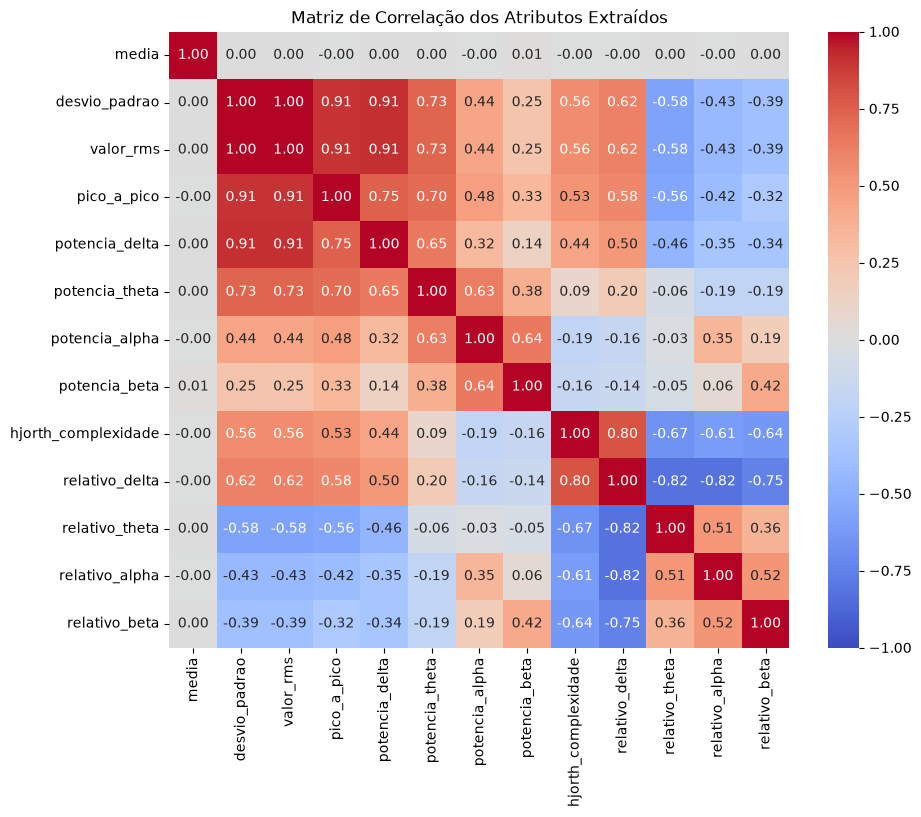

In [12]:
# Lista de colunas de entrada (Features). Apenas as colunas numéricas de atributos.
features_cols = [
    "media", "desvio_padrao", "valor_rms", "pico_a_pico",
    "potencia_delta", "potencia_theta", "potencia_alpha", "potencia_beta", "hjorth_complexidade",
    "relativo_delta", "relativo_theta", "relativo_alpha", "relativo_beta"
]
matriz_corr = df[features_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação dos Atributos Extraídos")
plt.show()

Conforme observado na matriz de correlação, atributos como `valor_rms` e `potencia_delta` possuem correlação de 0,95, sendo redundantes. Vamos testar o modelo removendo variáveis altamente correlacionadas ou menos informativas para diminuir a complexidade.

# Preparação para Modelagem

Nesta seção são definidas as variáveis comuns usadas pelos modelos. A matriz `X` contém os atributos selecionados após a análise de redundância, enquanto `y` contém o alvo numérico (`id_estagio`). Essa separação evita repetir a mesma preparação dentro de cada modelo.


In [13]:
# Lista de colunas de entrada (Features).
features_cols = [
    'variancia' , 'assimetria', 'curtose_excesso', 'potencia_delta',
    'potencia_theta', 'potencia_alpha', 'potencia_beta', 'relativo_delta',
    'relativo_theta', 'relativo_alpha', 'relativo_beta', 'razao_alpha_theta', 'hjorth_complexidade'
]

X = df[features_cols]
y = df['id_estagio'] # Alvo numérico para classificação

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (21039, 13)
Shape de y: (21039,)


# Modelo 1: K-Nearest Neighbors (KNN) <font color="blue">(Ícaro)</font>

O K-Nearest Neighbors (KNN) é um algoritmo de aprendizado supervisionado baseado em instâncias, o que significa que ele não ajusta uma equação paramétrica explícita durante o treinamento. Em vez disso, ele armazena os exemplos de treino e classifica uma nova amostra com base na similaridade.

## Intuição e Funcionamento
A regra de decisão do KNN é simples: dado um novo ponto de dado, o algoritmo calcula a sua distância em relação aos exemplos rotulados, identifica os *k* vizinhos mais próximos e atribui a esse novo ponto a classe mais frequente entre esses vizinhos (votação majoritária).

Seu desempenho depende criticamente de dois fatores:

- Escala das Variáveis: Como o KNN baseia-se em cálculos de distância, atributos com escalas numéricas maiores (como a Potência Delta) podem dominar o cálculo e distorcer a classificação. Por isso, a padronização via *StandardScaler* é obrigatória para padronizar as variáveis: média 0 e desvio padrão 1.
- Escolha do Hiperparâmetro *k*: O valor de *k* controla a complexidade do modelo.

  - Um k muito pequeno (ex.: k = 1) torna o modelo muito sensível a ruídos locais, aumentando o risco de **sobreajuste** (*overfitting*).
  - Um k muito grande (ex.: k = 31) torna a fronteira de decisão suave demais, podendo ignorar padrões locais importantes e causar **subajuste** (*underfitting*).

## Divisão Treino/Teste

A base de dados é desbalanceada, com forte predominância da classe N2 e raridade da classe N1. Por isso, foi utilizada uma estratégia de divisão que respeita tanto o desbalanceamento quanto a estrutura temporal dos dados.

Foi empregado `GroupShuffleSplit` para separar **noites inteiras** (`chavepar`) entre treino e teste. Essa abordagem é mais rigorosa que a divisão aleatória estratificada, pois evita o vazamento de informação entre épocas da mesma noite, simulando melhor o cenário real de aplicação em novos pacientes.

In [14]:
from sklearn.model_selection import GroupShuffleSplit, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Divisão por Noite
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)

for train_idx, test_idx in gss.split(X, y, groups=df['chavepar']):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    break

print(f"Treino: {X_train.shape[0]} épocas ({df.iloc[train_idx]['chavepar'].nunique()} noites)")
print(f"Teste : {X_test.shape[0]} épocas  ({df.iloc[test_idx]['chavepar'].nunique()} noites)")

Treino: 14500 épocas (14 noites)
Teste : 6539 épocas  (6 noites)


### Estratégia de Separação por Noites Inteiras

A divisão dos dados foi realizada por meio do `GroupShuffleSplit`, separando **noites inteiras** (`chavepar`) entre os conjuntos de treino e teste. Essa estratégia foi adotada intencionalmente para evitar vazamento de informação temporal e inter-paciente.

Diferentemente do `train_test_split` convencional (mesmo quando utilizado com estratificação por classe), que distribui as épocas de forma aleatória e individual, o `GroupShuffleSplit` garante que todas as épocas pertencentes à mesma noite permaneçam juntas, seja no treino ou no teste. 

Caso fosse utilizada a divisão aleatória convencional, o modelo teria acesso, durante o treinamento, a informações altamente correlacionadas com as amostras de teste. Isso geraria uma estimativa de desempenho **otimista e irrealista**, pois o modelo estaria "vendo" padrões muito semelhantes aos do teste, inflando artificialmente as métricas de avaliação, especialmente recall e precisão das classes minoritárias (como N1 e REM).

A abordagem com `GroupShuffleSplit`, embora mais rigorosa e desafiadora, simula de forma mais fiel o cenário clínico real, no qual o sistema deve generalizar para novos pacientes e novas noites de sono, fornecendo uma avaliação mais confiável e reprodutível dos resultados.

## Seleção de *k*

Para encontrar o equilíbrio ideal entre viés e variância, não escolheremos o valor de *k* de forma arbitrária. Utilizaremos a **Validação Cruzada Estratificada** com 5 *folds*, aplicada apenas ao conjunto de treino para estimar qual o melhor hiperparâmetro *k* do algoritmo KNN apresenta a melhor capacidade de generalização para dados inéditos.

Essa estratégia garante que a proporção dos diferentes estágios do sono seja respeitada em cada partição. Além disso, o uso de um `Pipeline` (contendo normalização + classificador) é fundamental, pois garante que a padronização dos dados seja recalculada em cada *fold*, prevenindo vazamento de informação entre treino e validação.

In [15]:
# Validação Cruzada (dentro do treino)
k_values = list(range(1, 42, 2))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_scores = []
cv_means = []
test_scores = []

for k in k_values:
    knn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='manhattan')),
    ])

    knn_model.fit(X_train, y_train)
    train_scores.append(knn_model.score(X_train, y_train))
    test_scores.append(knn_model.score(X_test, y_test))

    scores = cross_val_score(knn_model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_means.append(scores.mean())

# Melhor k
best_idx = int(np.argmax(cv_means))
best_k = k_values[best_idx]
print(f"Melhor k por validação cruzada: {best_k}")

Melhor k por validação cruzada: 17


## Viés, Variância e *k*

O gráfico a seguir apresenta a evolução da acurácia em função do número de vizinhos (*k*), comparando dois cenários principais:

- **Curva Azul (Treino)**: Desempenho no conjunto de dados usado para ajustar o modelo. Com *k* = 1, a acurácia tende a 100%, o que indica alta variância e forte tendência a sobreajuste.
- **Curva Verde (Validação Cruzada)**: Média de acurácia obtida por Validação Cruzada Estratificada (5 *folds*) no conjunto de treino. Essa curva fornece uma estimativa mais robusta e realista do desempenho esperado do modelo.

A linha vertical tracejada marca o melhor valor de *k* selecionado com base na acurácia média da validação cruzada. 

Acurácia no TREINO (modelo final): 0.7955 | Erro de Treino : 0.2045
Acurácia no TESTE  (modelo final): 0.6863 | Erro de Generalização : 0.3137
Gap (Treino - Teste): 0.1092 (10.92%)


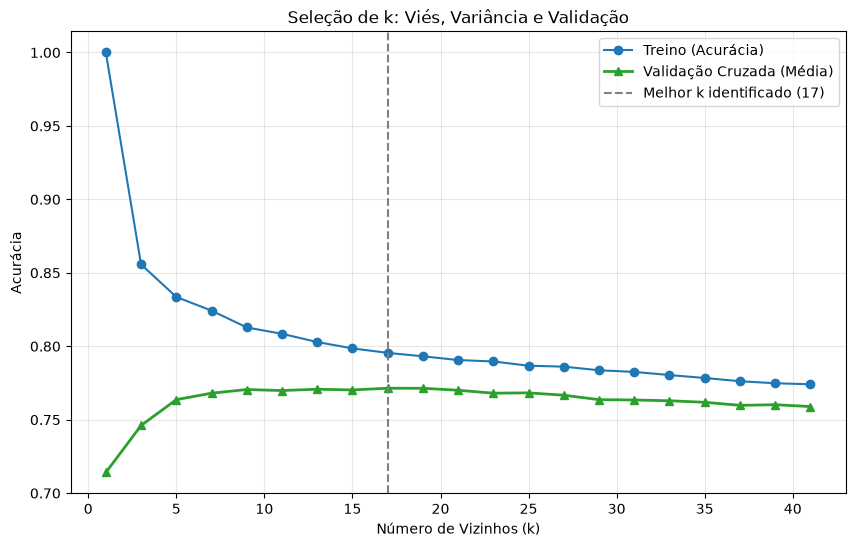

In [16]:
from sklearn.metrics import accuracy_score

# Treinamento do modelo final com o melhor k
knn_best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k, weights='uniform', metric='manhattan')),
])

knn_best_model.fit(X_train, y_train)

# Avaliação Final do Modelo (Acurácia + Erro)
y_pred_train = knn_best_model.predict(X_train)
y_pred_test  = knn_best_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy  = accuracy_score(y_test, y_pred_test)

# Cálculo dos erros (1 - acurácia)
train_error = 1 - train_accuracy
test_error  = 1 - test_accuracy
gap = train_accuracy - test_accuracy

print(f"Acurácia no TREINO (modelo final): {train_accuracy:.4f} | Erro de Treino : {train_error:.4f}")
print(f"Acurácia no TESTE  (modelo final): {test_accuracy:.4f} | Erro de Generalização : {test_error:.4f}")
print(f"Gap (Treino - Teste): {gap:.4f} ({gap*100:.2f}%)")

# Gráfico de Seleção de k
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, marker='o', label='Treino (Acurácia)', color='#1f77b4')
plt.plot(k_values, cv_means, marker='^', label='Validação Cruzada (Média)', color='#2ca02c', linewidth=2)

plt.axvline(best_k, color='gray', linestyle='--', label=f'Melhor k identificado ({best_k})')

plt.title('Seleção de k: Viés, Variância e Validação')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Interpretação do Gráfico de Seleção de *k*

A análise do gráfico revela um comportamento típico do algoritmo KNN. Observa-se que, para *k* = 1, a acurácia no conjunto de treino atinge próximo de 100%, configurando um forte sobreajuste (alta variância). Nessa configuração, o modelo tende a memorizar os exemplos do conjunto de treinamento, o que explica a elevada acurácia observada, porém compromete sua capacidade de generalização para novos dados. À medida que *k* aumenta, a acurácia no treino diminui, enquanto a estimativa obtida por Validação Cruzada (curva verde) sobe inicialmente e depois estabiliza.

O melhor valor de *k* identificado foi ***k* = 17**, selecionado com base na acurácia média obtida por validação cruzada estratificada. Nesse ponto, o modelo final alcançou 79,55% de acurácia no conjunto de treino e 68,63% no conjunto de teste, resultando em um *gap* (lacuna) de 10,92%.

Segundo Géron (*Hands-On Machine Learning*), o *overfitting* ocorre quando o modelo apresenta baixo erro no treinamento, mas alto erro de generalização no teste. Essa discrepância evidencia que o modelo "memorizou" padrões específicos dos pacientes da base de treino, os quais não se repetem integralmente nos novos pacientes. Tal comportamento aponta para uma variância moderada e revela limitações na capacidade de generalização. Esse cenário é particularmente comum em sinais biológicos, dada a alta variabilidade interpaciente e o forte desbalanceamento da base, com acentuado predomínio da classe N2.

A queda de desempenho no conjunto de teste reforça a relevância da estratégia de separação por noites inteiras, simulando de forma mais realista o cenário clínico, onde o sistema deve atuar em dados de novos indivíduos.

A escolha de *k* = 17 representa um equilíbrio razoável, pois valores menores de *k* levariam a maior variância, enquanto valores muito altos aumentariam o viés, tornando o modelo excessivamente simplificado.

## Avaliação de Desempenho

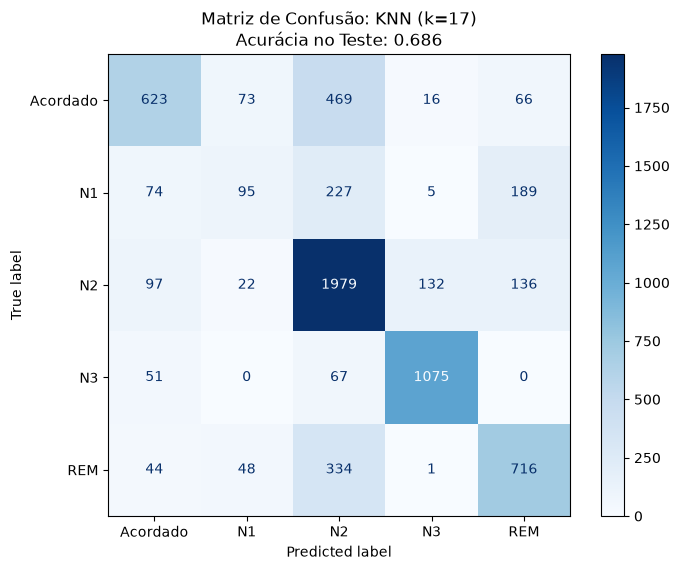


Relatório de Classificação (Teste):
              precision    recall  f1-score   support

    Acordado      0.701     0.500     0.583      1247
          N1      0.399     0.161     0.229       590
          N2      0.643     0.836     0.727      2366
          N3      0.875     0.901     0.888      1193
         REM      0.647     0.626     0.636      1143

    accuracy                          0.686      6539
   macro avg      0.653     0.605     0.613      6539
weighted avg      0.675     0.686     0.668      6539


Relatório detalhado por classe (Teste):
Acordado: 623/1247 (Acurácia: 0.500)
N1: 95/590 (Acurácia: 0.161)
N2: 1979/2366 (Acurácia: 0.836)
N3: 1075/1193 (Acurácia: 0.901)
REM: 716/1143 (Acurácia: 0.626)


In [17]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# Matriz de Confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    display_labels=list(IdPraClassificacao.values()),  # garantindo que seja lista
    cmap="Blues",
    ax=ax
)
ax.set_title(f"Matriz de Confusão: KNN (k={best_k})\nAcurácia no Teste: {test_accuracy:.3f}")
ax.grid(False)
plt.show()

# Relatório completo de classificação
print("\nRelatório de Classificação (Teste):")
print(classification_report(y_test, y_pred_test,
                           target_names=list(IdPraClassificacao.values()),
                           digits=3))

# Relatório detalhado por classe
print("\nRelatório detalhado por classe (Teste):")
for classe, nome in IdPraClassificacao.items():
    total = (y_test == classe).sum()
    correct = ((y_test == classe) & (y_pred_test == classe)).sum()
    acc = correct / total if total > 0 else 0
    print(f"{nome}: {correct}/{total} (Acurácia: {acc:.3f})")

## Interpretação dos Resultados do Modelo KNN

A análise conjunta do gráfico de seleção de *k*, da matriz de confusão e do relatório de classificação permite uma compreensão mais profunda do desempenho do modelo.

## Análise da Matriz de Confusão

A matriz de confusão revela que o gap de desempenho não se distribui de forma uniforme entre as classes, estando **fortemente concentrado nas classes minoritárias**:

- A classe **N2** (majoritária) é bem classificada (2366 acertos), contribuindo significativamente para a acurácia geral.
- A classe **N3** também apresenta bom desempenho (recall de 90,1%).
- Por outro lado, a classe **N1** (sono leve) é a mais problemática, com recall de apenas **16,1%**, sendo grande parte das épocas confundida com N2.
- A classe **REM** demonstra dificuldade moderada (recall de 62,6%), também frequentemente confundida com N2.

Essa distribuição indica que o gap de 10,92% é causado principalmente pela dificuldade do modelo em distinguir o estágio N1 e, em menor grau, o REM dos demais estágios. Tal comportamento é consistente com a natureza dos dados: o estágio N1 possui características eletrofisiológicas sutis e transitórias, tornando-o particularmente desafiador para um classificador baseado em distância como o KNN.

## Implicações do Desbalanceamento

O forte desbalanceamento da base, com N2 representando cerca de 42,43% da base e N1 em torno de 8,03% da base, agrava o problema. Como o KNN é um algoritmo baseado em votação de vizinhos, ele tende a favorecer as classes majoritárias, explicando por que o modelo “prefere” classificar épocas duvidosas como N2.

## Conclusão

O *gap* de 12,01% observado entre a acurácia de treinamento e a de teste evidencia a presença de **variância** no modelo, indicando que o algoritmo KNN capturou ruídos e particularidades do conjunto de treinamento que não se aplicam integralmente ao novo paciente. Este fenômeno é agravado pela variabilidade inter-paciente, onde as características fisiológicas do sono mudam entre indivíduos.

Neste cenário de monitoramento do sono, a **acurácia isolada demonstra-se insuficiente** para atestar a qualidade do sistema. Como a base é inerentemente desbalanceada, com o estágio N2 representando a classe majoritária e o N1 a classe minoritária, o modelo pode atingir uma acurácia global enganosamente alta ao privilegiar o estágio N2. Um classificador que "decorasse" apenas o comportamento do estágio N2 teria um desempenho estatístico satisfatório, mas seria clinicamente inútil por falhar na detecção de transições críticas.

A análise detalhada via **Recall** e **F1-Score** confirmou que o erro está concentrado nas classes minoritárias: o estágio **N1 obteve apenas 16,1% de sensibilidade**, sendo frequentemente confundido com o N2 devido à sua natureza instável e transitória. Esses achados reforçam a necessidade de explorar modelos mais robustos e métricas que valorizem a detecção correta de todos os estágios, garantindo a utilidade clínica e a segurança do diagnóstico automático.

# Modelo 2: Support Vector Machine (SVM) <font color="red">(Gabriel)</font>

O Support Vector Machine (SVM) é um algoritmo de aprendizado supervisionado que busca separar as classes por meio de uma fronteira de decisão com a maior margem possível entre os exemplos de diferentes categorias. No contexto deste trabalho, o objetivo é classificar cada época de EEG em um dos estágios do sono: Acordado, N1, N2, N3 ou REM.

## Intuição e Funcionamento
A ideia central do SVM é encontrar um hiperplano de separação que maximize a distância entre a fronteira de decisão e os exemplos mais próximos de cada classe, chamados de vetores de suporte. Esses vetores são os pontos mais importantes para definir a separação entre as classes.

Como os estágios do sono não necessariamente são separáveis por uma fronteira linear simples, utilizamos o kernel RBF (_Radial Basis Function_). Esse kernel permite projetar os dados para um espaço de maior complexidade, onde padrões não lineares entre as características extraídas do EEG podem ser melhor separados.

Seu desempenho depende principalmente de três fatores:

- Escala das Variáveis: O SVM é sensível à escala dos atributos, pois o cálculo da margem e do kernel depende das distâncias entre amostras. Por isso, assim como no KNN, utilizamos `StandardScaler` dentro de um `Pipeline`, garantindo que a padronização seja ajustada apenas com os dados de treino em cada etapa.
- Parâmetro C: Controla o compromisso entre maximizar a margem e penalizar erros de classificação. Valores baixos de `C` permitem uma margem mais flexível, enquanto valores altos tornam o modelo mais rígido e podem aumentar o risco de sobreajuste.
- Parâmetro gamma: Controla o alcance da influência de cada amostra no kernel RBF. Valores pequenos geram fronteiras mais suaves, enquanto valores altos tornam a fronteira mais local e mais sensível a variações específicas dos dados.

## Estratégia de Otimização

Para evitar uma escolha arbitrária dos hiperparâmetros, utilizamos `GridSearchCV` testando combinações de `C` e `gamma`. A métrica de seleção é o **F1-score macro**, pois a base possui desbalanceamento entre os estágios do sono e essa métrica atribui peso semelhante a todas as classes.

Diferentemente da divisão por épocas, a avaliação do SVM foi organizada por noite (`chavepar`). Assim, as épocas de uma mesma noite não aparecem simultaneamente no treino e no teste. Essa estratégia reduz vazamento de informação entre conjuntos e torna a avaliação mais próxima de um cenário real, no qual o modelo precisa generalizar para noites que não foram vistas durante o treinamento.


Noites totais no SVM: 20
Noites no treino: 14 | Noites no teste: 6
Épocas no treino: 14500 | Épocas no teste: 6539
Noites de teste: ['SC4001E', 'SC4002E', 'SC4022E', 'SC4041E', 'SC4072E', 'SC4082E']
Melhores hiperparâmetros por validação cruzada: {'svc__C': 100, 'svc__gamma': 0.01}
F1 macro médio de validação: 0.681
Acurácia no TREINO (modelo final): 0.7897
Acurácia no TESTE  (modelo final): 0.7104
F1 macro no TESTE: 0.6692
Gap (Treino - Teste): 0.0794 (7.94%)


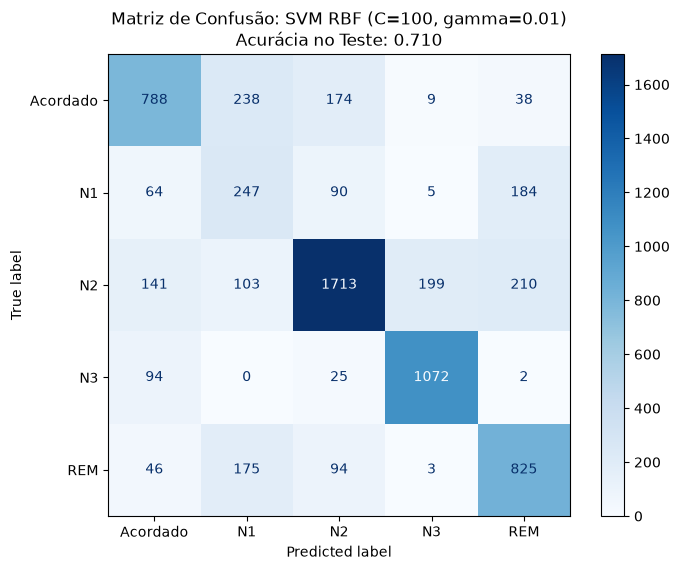


Relatório de Classificação (Teste):
              precision    recall  f1-score   support

    Acordado       0.70      0.63      0.66      1247
          N1       0.32      0.42      0.37       590
          N2       0.82      0.72      0.77      2366
          N3       0.83      0.90      0.86      1193
         REM       0.66      0.72      0.69      1143

    accuracy                           0.71      6539
   macro avg       0.66      0.68      0.67      6539
weighted avg       0.72      0.71      0.71      6539


Relatório detalhado por classe (Teste):
Acordado: 788/1247 (Acurácia: 0.632)
N1: 247/590 (Acurácia: 0.419)
N2: 1713/2366 (Acurácia: 0.724)
N3: 1072/1193 (Acurácia: 0.899)
REM: 825/1143 (Acurácia: 0.722)


In [18]:
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score

# Alteração feita pelo Gabriel: o SVM usa separação por noite (`chavepar`) para evitar
# que épocas da mesma noite apareçam ao mesmo tempo no treino e no teste.
groups_svm = df.loc[X.index, "chavepar"]
num_noites = groups_svm.nunique()

if num_noites < 2:
    raise RuntimeError(
        "O SVM precisa de pelo menos 2 noites para separar treino e teste por noite. "
        f"O DataFrame atual possui apenas {num_noites} noite(s): {sorted(groups_svm.unique())}. "
        "Reexecute as células de carregamento/processamento após corrigir o diretório do projeto."
    )

# Divisão 70/30 por noite: todas as épocas de uma mesma noite ficam apenas no treino ou apenas no teste.
svm_split = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(svm_split.split(X, y, groups=groups_svm))

X_train_svm = X.iloc[train_idx]
X_test_svm = X.iloc[test_idx]
y_train_svm = y.iloc[train_idx]
y_test_svm = y.iloc[test_idx]
groups_train_svm = groups_svm.iloc[train_idx]
groups_test_svm = groups_svm.iloc[test_idx]

print(f"Noites totais no SVM: {num_noites}")
print(f"Noites no treino: {groups_train_svm.nunique()} | Noites no teste: {groups_test_svm.nunique()}")
print(f"Épocas no treino: {X_train_svm.shape[0]} | Épocas no teste: {X_test_svm.shape[0]}")
print("Noites de teste:", sorted(groups_test_svm.unique()))

# Valores candidatos para os hiperparâmetros do SVM.
# C controla a penalização dos erros e gamma controla o alcance da influência de cada amostra.
svm_param_grid = {
    "svc__C": [0.1, 1, 10, 100, 1000],
    "svc__gamma": ["scale", 0.001, 0.01, 0.1, 1, 10],
}

# Pipeline com padronização e SVM RBF.
# Assim como no KNN, o scaler fica dentro do pipeline para evitar vazamento de dados.
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", class_weight="balanced", random_state=42)),
])

# Validação cruzada também por noite, sem misturar épocas da mesma noite entre folds.
n_splits_svm = min(5, groups_train_svm.nunique())
if n_splits_svm < 2:
    raise RuntimeError("GridSearchCV do SVM precisa de pelo menos 2 noites no conjunto de treino.")

svm_cv = GroupKFold(n_splits=n_splits_svm)

# Busca em grade usando F1 macro porque a base é desbalanceada.
svm_grid = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    scoring="f1_macro",
    cv=svm_cv,
    n_jobs=-1,
    refit=True,
)
svm_grid.fit(X_train_svm, y_train_svm, groups=groups_train_svm)

# Melhor modelo segundo a validação cruzada.
svm_best_model = svm_grid.best_estimator_
best_svm_params = svm_grid.best_params_
best_svm_cv = svm_grid.best_score_

print("Melhores hiperparâmetros por validação cruzada:", best_svm_params)
print(f"F1 macro médio de validação: {best_svm_cv:.3f}")

# Avaliação do Modelo Final (Treino + Teste)
y_pred_train = svm_best_model.predict(X_train_svm)
y_pred_test = svm_best_model.predict(X_test_svm)

# Cálculo das métricas
train_accuracy = accuracy_score(y_train_svm, y_pred_train)
test_accuracy = accuracy_score(y_test_svm, y_pred_test)
test_f1_macro = f1_score(y_test_svm, y_pred_test, average="macro", zero_division=0)

def formatar_parametros_svm(params):
    return f"C={params['svc__C']}, gamma={params['svc__gamma']}"

print(f"Acurácia no TREINO (modelo final): {train_accuracy:.4f}")
print(f"Acurácia no TESTE  (modelo final): {test_accuracy:.4f}")
print(f"F1 macro no TESTE: {test_f1_macro:.4f}")
print(f"Gap (Treino - Teste): {train_accuracy - test_accuracy:.4f} ({(train_accuracy - test_accuracy)*100:.2f}%)")

labels_svm = list(IdPraClassificacao.keys())
target_names_svm = list(IdPraClassificacao.values())

# Matriz de Confusão e Relatórios
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_svm,
    y_pred_test,
    labels=labels_svm,
    display_labels=target_names_svm,
    cmap="Blues",
    ax=ax
)
ax.set_title(
    f"Matriz de Confusão: SVM RBF ({formatar_parametros_svm(best_svm_params)})\n"
    f"Acurácia no Teste: {test_accuracy:.3f}"
)
ax.grid(False)
plt.show()

# Relatório completo
print("\nRelatório de Classificação (Teste):")
print(
    classification_report(
        y_test_svm,
        y_pred_test,
        labels=labels_svm,
        target_names=target_names_svm,
        zero_division=0,
    )
)

# Relatório detalhado por classe
print("\nRelatório detalhado por classe (Teste):")
for classe, nome in IdPraClassificacao.items():
    total = (y_test_svm == classe).sum()
    correct = ((y_test_svm == classe) & (y_pred_test == classe)).sum()
    acc = correct / total if total > 0 else 0
    print(f"{nome}: {correct}/{total} (Acurácia: {acc:.3f})")


# Modelo 3: Regressão Logística <font color="green">(Wendell)</font>



## Intuição e Funcionamento

A ideia central da Regressão Logística (em sua versão multinomial) é encontrar fronteiras de decisão lineares que separem as classes, utilizando uma função matemática para calcular a chance de uma época pertencer a cada estágio fisiológico. O modelo prevê a classe que obtiver a maior probabilidade.

Como os padrões biológicos dos estágios do sono não necessariamente são separáveis por uma fronteira linear simples, utilizamos a transformação `PolynomialFeatures` (de grau 2). Esse método cria novas características a partir da multiplicação e interação das variáveis originais, projetando os dados de forma que a Regressão Logística consiga capturar relações complexas e não lineares do EEG.

Seu desempenho depende principalmente de três fatores:

* **Escala das Variáveis:** A Regressão Logística, especialmente quando regularizada e combinada com termos polinomiais, é extremamente sensível à escala dos atributos (uma variável com números grandes ofuscaria as outras). Por isso, utilizamos o `StandardScaler` dentro de um `Pipeline`, garantindo que a padronização seja calculada de forma justa, apenas com os dados de treino em cada etapa.
* **Parâmetro C:** Controla a força da regularização (penalidade) aplicada ao modelo. Valores baixos de `C` aplicam uma penalidade forte, limitando os coeficientes e evitando o sobreajuste (overfitting) que poderia ser causado pelo excesso de variáveis polinomiais. Valores altos de `C` relaxam essa penalidade, tornando o modelo mais flexível aos dados de treino.
* **Pesos das Classes:** Controla a importância dada a cada categoria através do parâmetro `class_weight`. Como o sono é naturalmente desbalanceado (fases N2 são longas; N1 são curtas), utilizamos dicionários de pesos para penalizar mais o algoritmo quando ele erra as classes minoritárias, forçando-o a prestar atenção a todos os estágios.


In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

features_cols = [
    "media", "desvio_padrao", "pico_a_pico",
    "potencia_delta", "potencia_theta", "potencia_alpha", "potencia_beta", "hjorth_complexidade",
    "relativo_delta", "relativo_theta", "relativo_alpha", "relativo_beta", "razao_alpha_theta"
]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
idx_treino, idx_teste = next(gss.split(df, df['id_estagio'], groups=df['chavepar']))

df_treino = df.iloc[idx_treino].reset_index(drop=True)
df_teste = df.iloc[idx_teste].reset_index(drop=True)

# Vetorização direta
X_treino = df_treino[features_cols].values
Y_treino = df_treino['id_estagio'].values
grupos_treino = df_treino['chavepar'].values

X_teste = df_teste[features_cols].values
Y_teste = df_teste['id_estagio'].values

print("Preparando o Pipeline da Regressão Logística")
pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("logreg", LogisticRegression(max_iter=5000, random_state=42, solver='lbfgs'))
])

regularizacao = {
    "logreg__C" : [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    "logreg__class_weight" : [
        "balanced",
        {1: 1.0, 2: 1.5, 3: 1.0, 4: 1.0, 5: 1.0},
        {1: 1.0, 2: 2.0, 3: 0.9, 4: 1.0, 5: 1.5},
        {1: 1.0, 2: 5.0, 3: 0.9, 4: 1.0, 5: 1.0}
    ]
}

Preparando o Pipeline da Regressão Logística


### Estratégia de Otimização e Avaliação de Desempenho

A etapa de treinamento do modelo não se resume a apenas "ensinar" o algoritmo, mas sim a submetê-lo a uma bateria rigorosa de testes para encontrar sua melhor configuração e garantir que ele realmente aprendeu as regras biológicas do sono, em vez de simplesmente memorizar os dados. Esse processo é dividido nas seguintes frentes:

**1. Validação Cruzada com Isolamento de Pacientes**
Para garantir que o modelo seja capaz de generalizar o aprendizado para novos indivíduos, utiliza-se uma técnica de validação cruzada agrupada. O conjunto de treinamento é dividido em múltiplas partes (ou "dobras"). O modelo é treinado em algumas dessas partes e testado na restante, repetindo esse ciclo várias vezes. 

O grande diferencial metodológico aqui é o isolamento por grupo: o algoritmo é configurado para garantir que todas as épocas de sono de um mesmo paciente permaneçam estritamente dentro da mesma dobra. Isso impede o "vazamento de dados" (quando o modelo reconhece o paciente em vez do estágio do sono), garantindo uma avaliação muito mais próxima de um cenário clínico real.

**2. Busca Exaustiva de Hiperparâmetros (Grid Search)**
Para não depender de "achismos" na configuração do modelo, o algoritmo é submetido a uma busca em grade. Esse processo testa, de forma automatizada e exaustiva, diversas combinações de parâmetros — como diferentes intensidades de regularização matemática e variados esquemas de pesos para as classes. 

Para decidir qual combinação é a vencedora, o sistema utiliza uma métrica de pontuação rigorosa (geralmente o *F1-score macro*). Como a arquitetura do sono é naturalmente desbalanceada (algumas fases duram horas, outras duram minutos), essa métrica avalia o desempenho de cada estágio separadamente antes de calcular uma média. Isso impede que o modelo seja considerado "bom" apenas por acertar a fase mais comum da noite, forçando-o a ser competente em todas.

**3. Treinamento e Seleção do Modelo Definitivo**
Após cruzar todas as combinações de hiperparâmetros através de todas as dobras da validação cruzada, o sistema identifica automaticamente a configuração que obteve a maior pontuação média. Esse "estimador vencedor" é então extraído e se torna o modelo definitivo, otimizado e pronto para realizar as previsões finais.

**4. Diagnóstico de Sobreajuste (Treino vs. Teste)**
A verdadeira prova de fogo ocorre quando o modelo recém-otimizado é avaliado em dois cenários distintos: nos dados que ele utilizou para estudar (Treino) e nos dados inéditos que estavam separados desde o início do projeto (Teste). 

A comparação entre esses dois relatórios de classificação permite um diagnóstico direto de *overfitting* (sobreajuste). Se o modelo apresentar métricas quase perfeitas no treino, mas um desempenho ruim no teste, significa que ele apenas "decorou" os dados. Se os resultados forem consistentes em ambos os conjuntos, comprova-se que o algoritmo aprendeu padrões generalizáveis.

**5. Transparência Clínica: Acurácia por Estágio**
Por fim, as métricas estatísticas gerais são desmembradas em uma avaliação específica para cada estágio fisiológico do sono. O sistema isola todas as ocorrências reais de uma determinada fase (como o sono REM, por exemplo) e calcula a porcentagem exata de quantas vezes o modelo conseguiu diagnosticá-la corretamente (métrica conhecida como Sensibilidade ou *Recall*). Essa transparência expõe as fortalezas e os pontos cegos do algoritmo, revelando aos pesquisadores exatamente quais transições do sono geram maior grau de confusão matemática.

In [23]:
print("Iniciando Otimização e Treinamento...")
gkf = GroupKFold(n_splits=5)
modelo_reg = GridSearchCV(estimator=pipeline, param_grid=regularizacao, cv=gkf, scoring="f1_macro", n_jobs=-1)

modelo_reg.fit(X_treino, Y_treino, groups=grupos_treino)
best_logreg = modelo_reg.best_estimator_

y_pred_treino = best_logreg.predict(X_treino)
y_pred_teste = best_logreg.predict(X_teste)

print(f"Treinamento concluído!\nHiperparâmetros Vencedores:\nC: {modelo_reg.best_params_['logreg__C']} | Pesos: {modelo_reg.best_params_['logreg__class_weight']}")

print("="*40)
print("=== DESEMPENHO NO TREINO ===")
print("="*40)
print(classification_report(Y_treino, y_pred_treino))

print("\n" + "="*40)
print("=== DESEMPENHO NO TESTE ===")
print("="*40)
print(classification_report(Y_teste, y_pred_teste))

print("\n" + "="*40)
print("=== ACURÁCIA POR ESTÁGIO (TESTE) ===")
print("="*40)

mapa_estagios = {
    1: "Acordado",
    2: "N1",
    3: "N2",
    4: "N3",
    5: "REM"
}

estagios_unicos = np.unique(Y_teste)

for estagio in estagios_unicos:
    nome_estagio = mapa_estagios.get(estagio, f"Estágio {estagio}")
    
    total_estagio = np.sum(Y_teste == estagio)
    acertos_estagio = np.sum((Y_teste == estagio) & (y_pred_teste == estagio))
    acuracia = acertos_estagio / total_estagio if total_estagio > 0 else 0
    
    print(f"{nome_estagio}: {acertos_estagio}/{total_estagio} ({acuracia:.2%})")

Iniciando Otimização e Treinamento...
Treinamento concluído!
Hiperparâmetros Vencedores:
C: 1 | Pesos: {1: 1.0, 2: 2.0, 3: 0.9, 4: 1.0, 5: 1.5}
=== DESEMPENHO NO TREINO ===
              precision    recall  f1-score   support

           1       0.83      0.70      0.76      2409
           2       0.45      0.44      0.45      1099
           3       0.87      0.87      0.87      6561
           4       0.87      0.89      0.88      1881
           5       0.69      0.79      0.73      2550

    accuracy                           0.80     14500
   macro avg       0.74      0.74      0.74     14500
weighted avg       0.80      0.80      0.80     14500


=== DESEMPENHO NO TESTE ===
              precision    recall  f1-score   support

           1       0.74      0.49      0.59      1247
           2       0.39      0.33      0.36       590
           3       0.71      0.83      0.77      2366
           4       0.91      0.87      0.89      1193
           5       0.64      0.74     

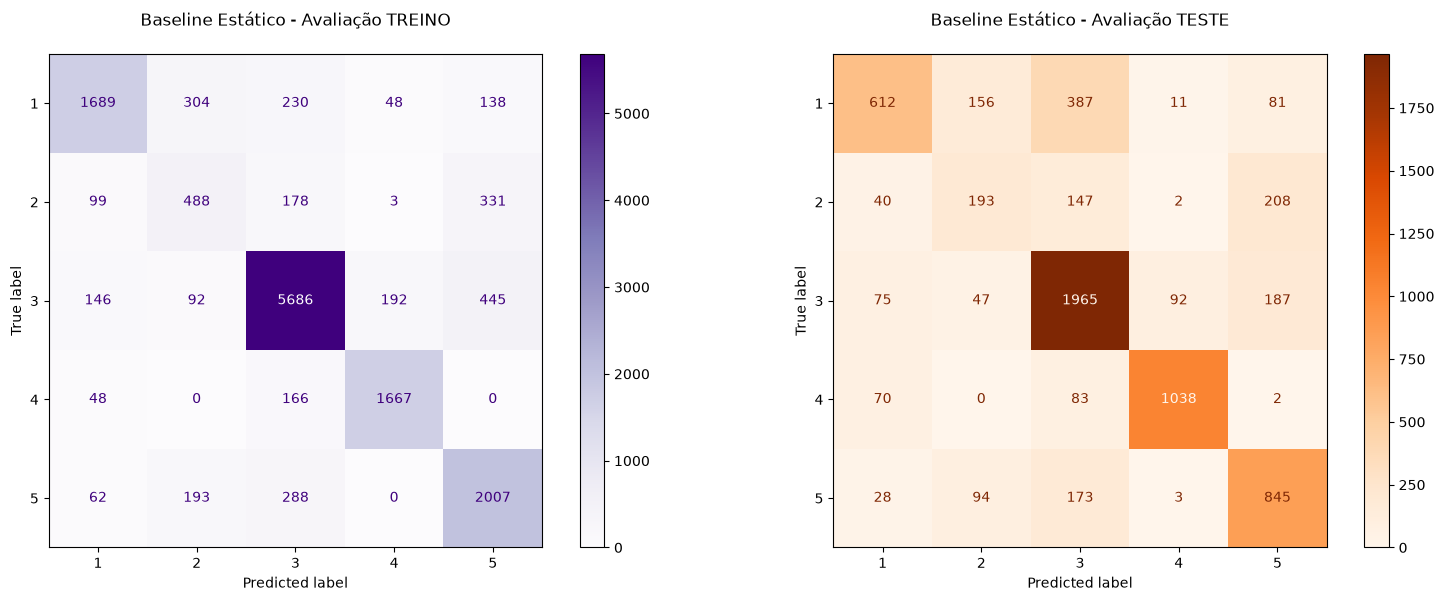

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz do Treino
ConfusionMatrixDisplay.from_predictions(Y_treino, y_pred_treino, cmap="Purples", ax=axes[0])
axes[0].set_title("Baseline Estático - Avaliação TREINO\n")

# Matriz do Teste
ConfusionMatrixDisplay.from_predictions(Y_teste, y_pred_teste, cmap="Oranges", ax=axes[1])
axes[1].set_title("Baseline Estático - Avaliação TESTE\n")

plt.tight_layout()
plt.show()

### Análise de Desempenho: Viés, Variância e o Desafio das Classes Minoritárias

A avaliação final do modelo de Regressão Logística revela *insights* importantes sobre sua capacidade de aprendizado e generalização, especialmente quando lidamos com dados biológicos complexos e desbalanceados. Para julgar esses resultados de forma técnica, precisamos analisar o comportamento do algoritmo sob a ótica do *Trade-off* entre Viés e Variância.

#### 1. Diagnóstico de Viés e Variância

* **Viés (Bias - Capacidade de Aprendizado): Baixo a Moderado**
    O modelo demonstra uma boa capacidade de aprender os padrões gerais do sono. No conjunto de treinamento, a acurácia global chegou a 80% e o F1-score macro a 74%. Isso indica que a combinação da Regressão Logística com as `PolynomialFeatures` (grau 2) foi suficiente para capturar a complexidade não linear dos sinais de EEG. O modelo não sofre de *underfitting* (alto viés) grave, pois consegue mapear regras matemáticas robustas para a maioria dos estágios.

* **Variância (Capacidade de Generalização): Moderada (Leve *Overfitting*)**
    Ao observar a transição do Treino para o Teste, notamos uma queda nas métricas. A acurácia global caiu de 80% para 71%, e o F1-score macro de 74% para 66%. Essa queda na performance em dados inéditos (pacientes nunca vistos pelo modelo) caracteriza uma variância moderada, ou seja, um grau aceitável de *overfitting*.
    * **Por que isso acontece?** A introdução de características polinomiais cria um espaço de variáveis muito complexo. Embora o hiperparâmetro de regularização `C=1` (vencedor do GridSearch) tenha ajudado a controlar a penalidade, o modelo ainda acabou "decorando" algumas peculiaridades biológicas dos pacientes do conjunto de treino que não se aplicam perfeitamente aos pacientes do conjunto de teste.

#### 2. O Impacto dos Pesos (Class Weights) e o Desempenho por Estágio

O hiperparâmetro vencedor para os pesos das classes foi `{1: 1.0, 2: 2.0, 3: 0.9, 4: 1.0, 5: 1.5}`, que foram escolhidos arbitrariamente por mim. Essa escolha matemática pelo `GridSearchCV` reflete uma tentativa do algoritmo de equilibrar a balança fisiológica da noite de sono:

* **O Desafio Crônico do Estágio N1 (Classe 2):**
    O estágio N1 é historicamente o mais difícil de ser classificado em *Machine Learning* para sono, pois é uma fase de transição (sono leve) cujas características de EEG frequentemente se misturam com o estado Acordado e com o estágio N2. No teste, a acurácia (recall) do N1 foi a menor de todas (32.71%). 
    * **O efeito dos pesos:** Para tentar mitigar esse problema, o modelo vencedor atribuiu o peso máximo (`2.0`) para o N1. Essa "multa" severa por erros forçou o modelo a ser mais sensível a essa classe, conseguindo elevar sua taxa de acerto para a casa dos 30%. Sem esse peso artificial, é muito provável que o N1 fosse quase totalmente ignorado pelo algoritmo e absorvido por outras classes.

* **O "Sacrifício" do Estágio N2 (Classe 3):**
    O estágio N2 domina a maior parte de uma noite de sono normal. Como consequência matemática do aumento do peso do N1 e do REM (`1.5`), o estágio N2 precisou ser penalizado com um peso menor (`0.9`). 
    * **O efeito prático:** Isso significa que o modelo aceitou errar um pouco mais no N2 (que já é uma classe "fácil" e abundante) para tentar salvar o desempenho do N1 e do REM. Apesar dessa penalidade intencional, a robustez do N2 é tão grande que ele ainda manteve uma excelente acurácia de 83.05% no teste.

* **A Força das Classes Extremas (N3 e REM):**
    Os estágios mais profundos e distintos apresentaram os melhores resultados de generalização. O sono de ondas lentas (N3) atingiu impressionantes 87.01% de acurácia no teste, e o REM alcançou 73.93%, demonstrando que as características de potência de frequência extraídas são excelentes preditores para esses estados biológicos.

#### Conclusão do Julgamento

O modelo atinge um equilíbrio louvável. A estratégia de inflar artificialmente o peso do N1 (mesmo sacrificando levemente a classe N2) provou-se correta ao tentar nivelar o F1-Score Macro. A queda de desempenho entre treino e teste (variância) é esperada e aceitável em cenários onde a divisão dos dados respeita o isolamento por paciente (`GroupShuffleSplit`), garantindo que o algoritmo de 71% de acurácia no teste reflete um desempenho clínico real, e não uma ilusão estatística.